# Notebook to Compare Experimental Heuristics with Base Heuristics

In [1]:
import random
import networkx as nx

from time import time
import matplotlib.pyplot as plt

random.seed(42)  # For accurate comparison

In [2]:
from src import (
    kempe_greedy,
    maximin_greedy,
    fair_greedy,
)

from src import (
    maximin_utility,
    estimate_influence_per_group,
)

## Small Graph Comparison

In [3]:
graph = nx.erdos_renyi_graph(
    n=20,
    p=0.15,
    directed=True,
    seed=42
)

groups = {node: random.choice(['A', 'B']) for node in graph.nodes}

group_sizes = {g: list(groups.values()).count(g) for g in set(groups.values())}

lower_bounds = {g: 2 for g in group_sizes}
upper_bounds = {g: 6 for g in group_sizes}

In [4]:
k = 6
probability = 0.1
num_simulations = 200

In [5]:
start = time()
kempe_seeds, kempe_spreads, _ = kempe_greedy(graph, k, probability, num_simulations)
kempe_time = time() - start
kempe_group_spread = estimate_influence_per_group(graph, kempe_seeds, groups, probability, num_simulations)
kempe_util = maximin_utility(kempe_group_spread, group_sizes)

Selecting seeds: 100%|██████████| 6/6 [00:00<00:00, 54.75it/s]


In [6]:
start = time()
maximin_seeds, maximin_utils, _ = maximin_greedy(graph, groups, k, probability, num_simulations)
maximin_time = time() - start
maximin_group_spread = estimate_influence_per_group(graph, maximin_seeds, groups, probability, num_simulations)
maximin_util = maximin_utility(maximin_group_spread, group_sizes)

Selecting seeds: 100%|██████████| 6/6 [00:00<00:00, 55.74it/s]


In [7]:
start = time()
fair_seeds, fair_gains, _ = fair_greedy(graph, k, groups, lower_bounds, upper_bounds, num_simulations, probability)
fair_time = time() - start
fair_group_spread = estimate_influence_per_group(graph, fair_seeds, groups, probability, num_simulations)
fair_util = maximin_utility(fair_group_spread, group_sizes)

Selecting seeds: 100%|██████████| 6/6 [00:00<00:00, 48.64it/s]


In [8]:
print("\n===== COMPARISON =====")
print(
    f"Kempe Greedy:\n  Seeds: {kempe_seeds}\n  Group Spread: {kempe_group_spread}\n  Maximin Utility: {kempe_util:.4f}\n  Time: {kempe_time:.2f}s")
print(
    f"\nGreedy Maximin:\n  Seeds: {maximin_seeds}\n  Group Spread: {maximin_group_spread}\n  Maximin Utility: {maximin_util:.4f}\n  Time: {maximin_time:.2f}s")
print(
    f"\nFair Greedy:\n  Seeds: {fair_seeds}\n  Group Spread: {fair_group_spread}\n  Maximin Utility: {fair_util:.4f}\n  Time: {fair_time:.2f}s")


===== COMPARISON =====
Kempe Greedy:
  Seeds: [14, 0, 6, 7, 4, 16]
  Group Spread: {'A': 6.43, 'B': 1.575}
  Maximin Utility: 0.3150
  Time: 0.13s

Greedy Maximin:
  Seeds: {0, 2, 4, 6, 14, 16}
  Group Spread: {'A': 5.42, 'B': 2.505}
  Maximin Utility: 0.3613
  Time: 0.11s

Fair Greedy:
  Seeds: {1, 6, 8, 10, 15, 16}
  Group Spread: {'A': 5.385, 'B': 2.41}
  Maximin Utility: 0.3590
  Time: 0.13s


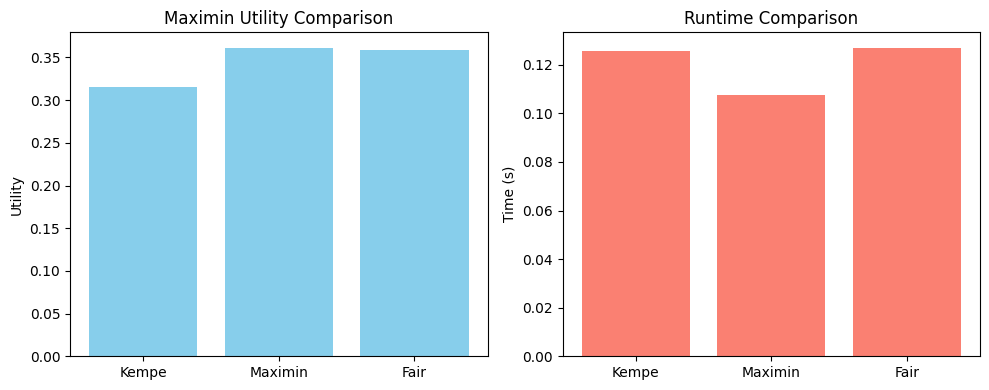

In [9]:
labels = ['Kempe', 'Maximin', 'Fair']
utils = [kempe_util, maximin_util, fair_util]
times = [kempe_time, maximin_time, fair_time]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(labels, utils, color='skyblue')
plt.title("Maximin Utility Comparison")
plt.ylabel("Utility")

plt.subplot(1, 2, 2)
plt.bar(labels, times, color='salmon')
plt.title("Runtime Comparison")
plt.ylabel("Time (s)")

plt.tight_layout()
plt.show()